In [1]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
base_path = Path("/content/drive/MyDrive/SOLVRO-ML/zad1") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

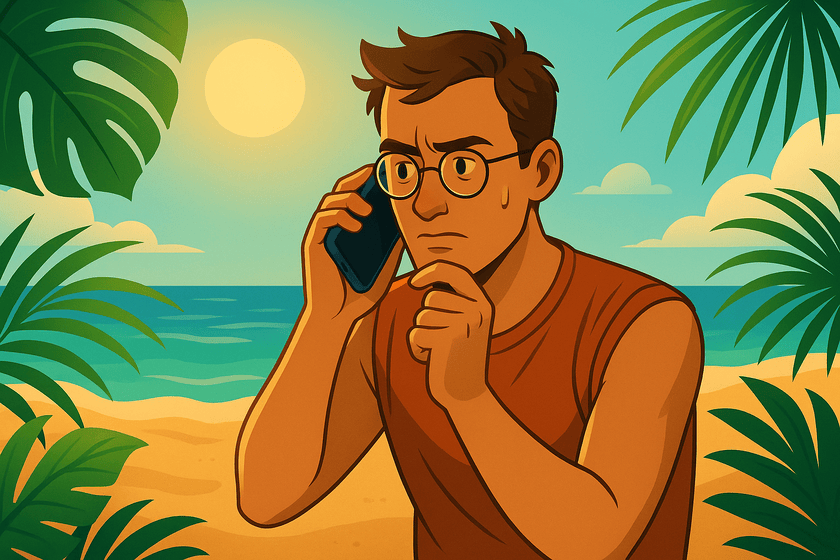

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [3]:
titanic_df = pd.read_csv("/content/drive/MyDrive/SOLVRO-ML/zad1/titanic.csv", index_col='PassengerId')

In [4]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


In [5]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [6]:
titanic_df.head()
titanic_df.info()
titanic_df.describe()

# najwięcej braków w kolumnach age, cabin i fare. W kolumnie Embarked brakuje tylko 2 znaczenia, to nie jest znacząca liczba.
# w Fare prawdopodobnie występuje rozkład skośny w prawo, mamy std większy niż średnie znaczenie.

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
print(titanic_df['Fare'].median())
print(titanic_df['Fare'].skew())
# dodatni skew pokazuje na skos rozkładu w prawo. Mediana także jest mniejsza od średniej. Mamy dużo biletów w niskiej cenie i mało bardzo drogich.

titanic_df.isna().mean() * 100 # procent pustych komórek w kolumnach

14.5
4.723906219805178


,0
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,10.998878
Cabin,77.104377


In [8]:
titanic_df[titanic_df['Age'].isna()]['Cabin'].isna().mean()

# wierszy bez znaczenia wieku pojawiają się częściej niż średnio, mając także brak znaczenia Cabin.

np.float64(0.8926553672316384)

In [9]:
missing_rows_mi = titanic_df.isna().mean(axis=1) * 100
missing_rows_mi.unique() #są wierszy w których brakuje 1-3 znaczenia

array([ 9.09090909,  0.        , 18.18181818, 27.27272727])

In [10]:
object_cols = titanic_df.select_dtypes(include='object').columns.drop('Name')
for col in object_cols:
    print(col, '-', titanic_df[col].nunique()) #sprawdziłam czy nie ma jakichś dziwnych kategorii, np. ze spacjami

Sex - 2
Ticket - 681
Cabin - 147
Embarked - 3


In [11]:
fare_check = titanic_df.groupby('Ticket')['Fare'].nunique()
fare_check.value_counts()
#Sprawdziłam czy cena za bilet jest sumą wszystkich osób na jednym bilecie, czy per osoba.
#Bo numerów biletów okazało się mniej niż rekordów w bazie, więc na jednym bilecie mogło być kilka osób (koledzy, rodzina, sługi).

#Przyjmuję założenie, że cena była wspólna za cały zespół, ponieważ u wszytstkich pasażerów mających jeden bilet zapisana jest jedna cena.
#62 biletów - tam gdzie brak ceny (Fare).

#To nie daje 100% gwarancji że faktycznie tak było, ale wydaje się bardzo prawdopodobne

,count
Fare,
1,619
0,62


In [12]:
titanic_df['TicketGroupSize'] = titanic_df.groupby('Ticket')['Ticket'].transform('count')
titanic_df['FarePerPerson'] = titanic_df['Fare'] / titanic_df['TicketGroupSize']
#dodałam kolumny z ilością osób na jednym bilecie oraz z ceną per osobę.

In [13]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1 #dodatkowa kolumna z sumą członków rodziny

print((titanic_df['FamilySize'] == titanic_df['TicketGroupSize']).mean())

titanic_df[titanic_df['FamilySize'] != titanic_df['TicketGroupSize']][['Name', 'SibSp', 'Parch', 'FamilySize', 'Ticket', 'TicketGroupSize']].head(10)

#Sprawdziłam jak mocno TicketGroupSize pokrywa się z już istniejącymi kolumnami zawierającymi liczbę członków rodziny na pokładzie.
#w 32% nie pokrywają się (na jednym bilecie mogli zajdować się osoby spoza rodziny, albo członkowie rodziny mieli różne bilety)

0.6767676767676768


,Name,SibSp,Parch,FamilySize,Ticket,TicketGroupSize
PassengerId,,,,,,
1,"Braund, Mr. Owen Harris",1,0,2,A/5 21171,1
2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2,PC 17599,1
8,"Palsson, Master. Gosta Leonard",3,1,5,349909,4
11,"Sandstrom, Miss. Marguerite Rut",1,1,3,PP 9549,2
17,"Rice, Master. Eugene",4,1,6,382652,5
19,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",1,0,2,345763,1
21,"Fynney, Mr. Joseph J",0,0,1,239865,2
25,"Palsson, Miss. Torborg Danira",3,1,5,349909,4
26,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",1,5,7,347077,4


In [14]:
titanic_df['Age'] = titanic_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
#Wypełniam brakujące znaczenia w kolumnie Age medianą. Ponieważ to liczbowy typ oraz dużo unikalnych znaczeń.
#Oraz biorę medianę dodatkowo w grupach z płcią i klasą, co może być powiązane z wiekiem.

In [15]:
titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
#Tu analogicznie, tylko grupujemy z klasą, bo cena bezpośrednio jest powiązana z klasą.
titanic_df['FarePerPerson'] = titanic_df['Fare'] / titanic_df['TicketGroupSize'] #powtórka, żeby usunąć braki z FarePerPerson

In [16]:
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])
#Brak tylko 2 znaczeń nie jest znaczący, więc można uzupełnić modą.

In [17]:
titanic_df['Cabin'].dropna().sample(15) #Zobaczyłam jak wyglądają surowe dane

,Cabin
PassengerId,
854,D28
292,B49
394,D36
216,D36
4,C123
263,E67
588,B41
149,F2
450,C104


In [18]:
titanic_df['Deck'] = titanic_df['Cabin'].str[0].fillna('Unknown')
#To nie są liczbowe dane, oraz jest dużo unikalnych znaczeń, także zawsze występuje litera w numerze,
#która odpowiada pokładowi, co już niesie ważną informacje.
#Więc zdecydowałam puste znaczenia wypełnić nową kategorią "Unknown", i wyodrębnić pozostałe kategorie według pokładu, odrzucając numer pokoju.

In [19]:
titanic_df[titanic_df['Cabin'].str.contains(' ', na=False)][['Cabin', 'Deck']].head()

def unique_decks(cabin_str):
    return set(c[0] for c in cabin_str.split())

titanic_df['Cabin'].dropna().apply(unique_decks).apply(len).value_counts()

#Zauważyłam że występują także rekordy, gdzie jeden pasażer mógł mieć kilka pokojów na różnych pokładach,
#ale takich przypadków jest tylko 4, więc zapisuje literę tylko pierwszego pokładu dla uproszczenia.

,count
Cabin,
1,200
2,4


In [20]:
titanic_df['Deck'].value_counts()
#Według danych https://www.encyclopedia-titanica.org/titanic-deckplans/ pokoje były od G (najniższy pokład) do A (najwyższy pokład) + kilka osobnych pokojów nad A (jedyna zapisana w naszym datasecie to T)

,count
Deck,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [21]:
titanic_df = titanic_df.drop(columns=['Cabin']) #Teraz można usunąć poprzednią tabele, bo już nie niesie dodatkowych danych.

In [22]:
titanic_df.isna().sum() #Sprawdzam czy już nie ma braków

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [23]:
#Sex - binarna kategoria
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

#Embarked - one-hot (3 kategorii bez porządku)
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], prefix='Embarked', dtype=int)

#Deck - one-hot (9 kategorii bez porządku)
titanic_df = pd.get_dummies(titanic_df, columns=['Deck'], prefix='Deck', dtype=int)

In [24]:
titanic_df = titanic_df.drop(columns=['Name', 'Ticket'])
#Kolumny imię i numer biletu nie mają już znaczących danych, więc można usunąć.

In [25]:
titanic_df.dtypes
titanic_df.head()
#Sprawdzam czy wszystkie znaczenia są teraz liczbowe.

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,TicketGroupSize,FarePerPerson,FamilySize,...,Embarked_S,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_Unknown
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,1,7.2500,2,...,1,0,0,0,0,0,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,1,71.2833,2,...,0,0,0,1,0,0,0,0,0,0
3,1,3,1,26.0,0,0,7.9250,1,7.9250,1,...,1,0,0,0,0,0,0,0,0,1
4,1,1,1,35.0,1,0,53.1000,2,26.5500,2,...,1,0,0,1,0,0,0,0,0,0
5,0,3,0,35.0,0,0,8.0500,1,8.0500,1,...,1,0,0,0,0,0,0,0,0,1


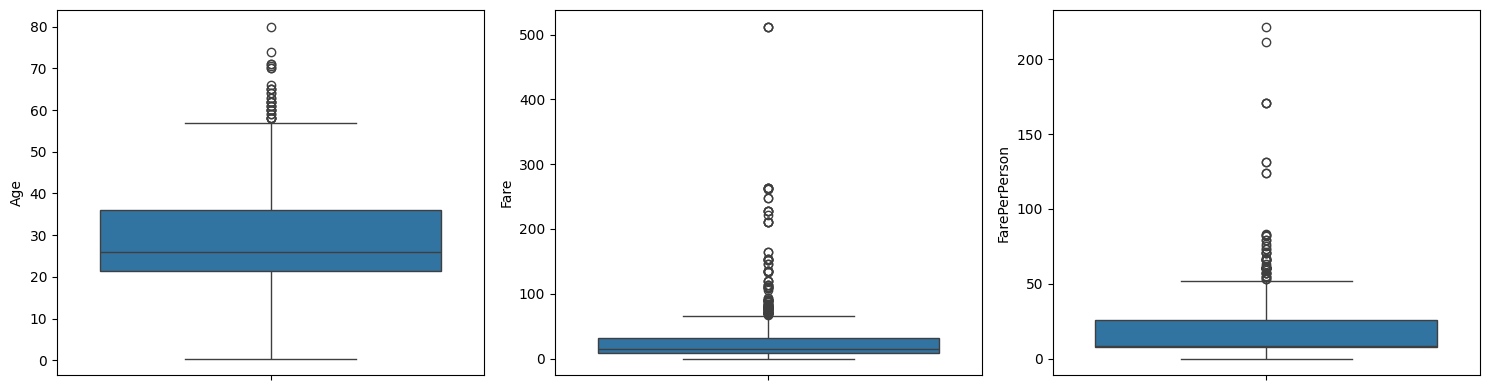

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=titanic_df['Age'], ax=axes[0])
sns.boxplot(y=titanic_df['Fare'], ax=axes[1])
sns.boxplot(y=titanic_df['FarePerPerson'], ax=axes[2])
plt.tight_layout()
plt.show()
#boxploty - wartości odstające liczbowo
#przy Fare i FarePerPerson widać sporo wartości odstających, długi ogon w góre, to najdroższe bilety

In [27]:
for col in ['Pclass', 'Sex'] + [c for c in titanic_df.columns if c.startswith(('Embarked_', 'Deck_'))]:
    print(col, '→', titanic_df[col].sum() if titanic_df[col].nunique() <= 2 else titanic_df[col].value_counts().to_dict())

#wartości "odstające" w kategoriach.
#tu widać że Deck_T i Deck_G mają bardzo mało obserwacji (1 i 4), więc to raczej rzadkie kategorie niż realne

Pclass → {3: 491, 1: 216, 2: 184}
Sex → 314
Embarked_C → 168
Embarked_Q → 77
Embarked_S → 646
Deck_A → 15
Deck_B → 47
Deck_C → 59
Deck_D → 33
Deck_E → 32
Deck_F → 13
Deck_G → 4
Deck_T → 1
Deck_Unknown → 687


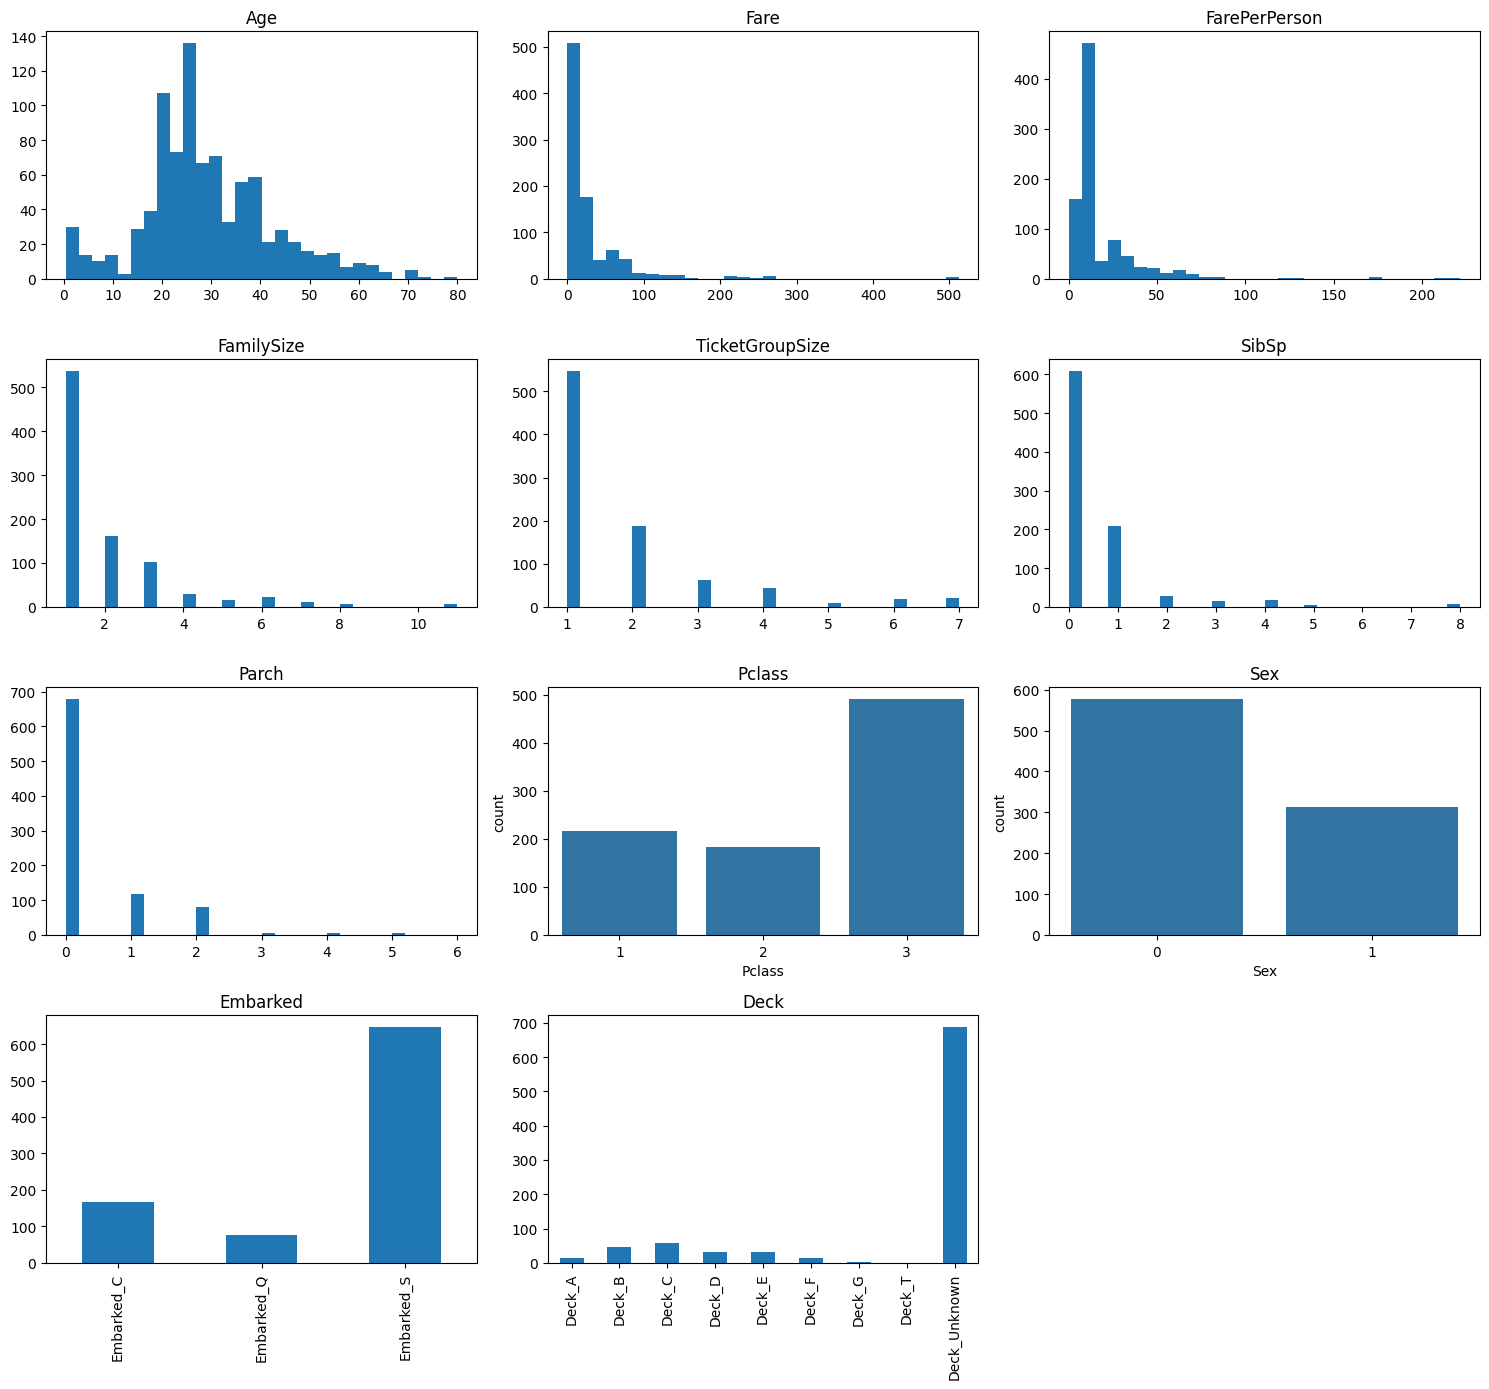

In [28]:
numeric_cols = ['Age', 'Fare', 'FarePerPerson', 'FamilySize', 'TicketGroupSize', 'SibSp', 'Parch']
embarked_cols = [c for c in titanic_df.columns if c.startswith('Embarked_')]
deck_cols = [c for c in titanic_df.columns if c.startswith('Deck_')]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(titanic_df[col], bins=30)
    axes[i].set_title(col)

sns.countplot(x='Pclass', data=titanic_df, ax=axes[7])
axes[7].set_title('Pclass')

sns.countplot(x='Sex', data=titanic_df, ax=axes[8])
axes[8].set_title('Sex')

titanic_df[embarked_cols].sum().plot(kind='bar', ax=axes[9])
axes[9].set_title('Embarked')

titanic_df[deck_cols].sum().plot(kind='bar', ax=axes[10])
axes[10].set_title('Deck')

axes[11].axis('off')

plt.tight_layout()
plt.show()

#pozostała wizualizacja
#rozkłady liczbowe (Fare, FarePerPerson) są mocno skośne, co już wiedziałam z wcześniejszego skew.
#kategorie mają różne proporcje, ale nic nowego względem tego co było liczone tekstowo wcześniej.

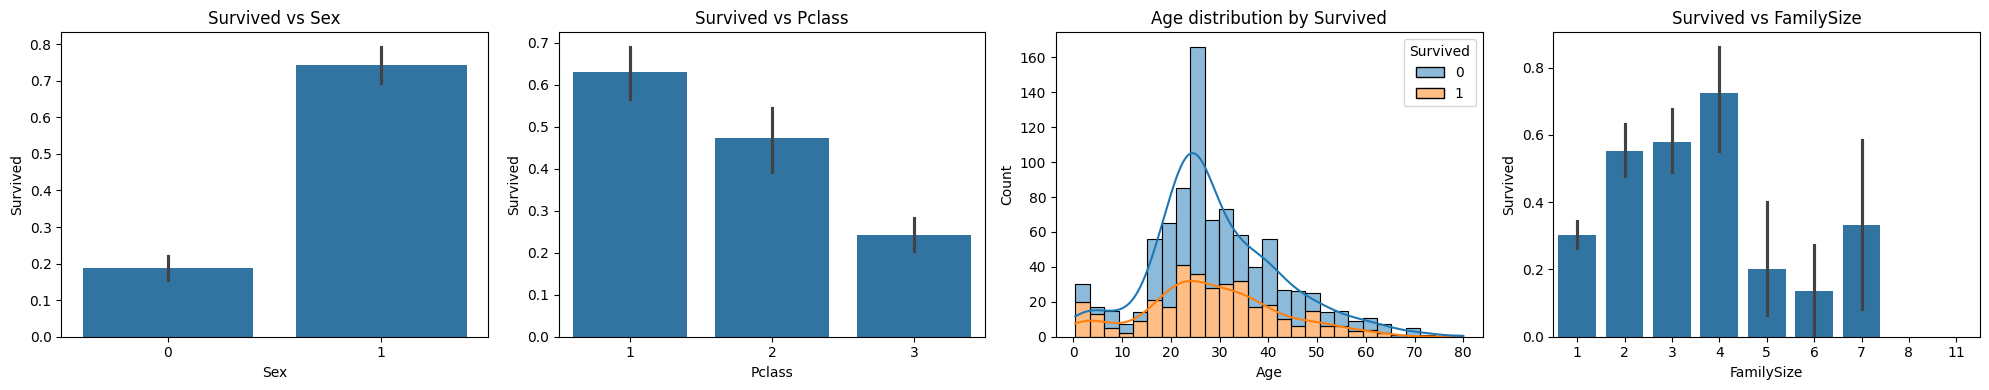

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

sns.barplot(x='Sex', y='Survived', data=titanic_df, ax=axes[0])
axes[0].set_title('Survived vs Sex')

sns.barplot(x='Pclass', y='Survived', data=titanic_df, ax=axes[1])
axes[1].set_title('Survived vs Pclass')

sns.histplot(data=titanic_df, x='Age', hue='Survived', kde=True, multiple='stack', ax=axes[2])
axes[2].set_title('Age distribution by Survived')

family_order = sorted(titanic_df['FamilySize'].unique())
sns.barplot(x='FamilySize', y='Survived', data=titanic_df, order=family_order, ax=axes[3])
axes[3].set_title('Survived vs FamilySize')

plt.tight_layout()
plt.show()

#Sprawdzam jak Survived wygląda względem innych cech.

#Płeć ma ogromną różnicę, kobiety przeżywały gdzieś 74%, mężczyźni tylko ~19%, to zdecydowanie najsilniejszy sygnał z całej analizy.

#Pclass też wyraźnie działa - im wyższa klasa, tym większa szansa na przeżycie, spadek jest w miarę równy między klasami.

#Age sam w sobie nie jest jakimś super mocnym predyktorem, ale widać że wśród najmłodszych dzieci
#przeżywalność jest trochę wyższa niż średnio, reszta rozkładu wygląda podobnie dla obu grup.

#FamilySize ma ciekawy, nieliniowy kształt, "single" przeżywały gorzej niż średnia,
#najlepiej wypadają rodziny średniej wielkości (2-4), a od 5 osób w górę przeżywalność mocno spada.
#Bary dla 8 i 11 osób bazują dosłownie na jednej rodzinie każdy, więc to nie jest wiarygodny trend, tylko pojedynczy przypadek.

#ogólnie Sex i Pclass wyglądają na najsilniejsze predyktory, Age i FamilySize dają dodatkowy, mniej oczywisty sygnał.